In [193]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

In [3]:
from probjax.inference.mcmc import MCMC
from probjax.inference.kernels import HMC, Slice

In [4]:
from diffusion_mri_models import Dti, Ball, Stick

In [23]:
# Stick
theta_true = jax.random.normal(jax.random.PRNGKey(100), (3,))*0.1
model = Stick.from_theta(theta_true)
print(model.lam, model.eigvec)

0.023134297 [0.99122643 0.13190055 0.00850579]


In [6]:
# Ball
theta_true = jax.random.normal(jax.random.PRNGKey(100), (1,))
model = Ball.from_theta(theta_true)
print(model.lam)

0.008161253


In [45]:
# DTI
theta_true = jax.random.normal(jax.random.PRNGKey(1), (6,))*2
model = Dti.from_theta(theta_true)
print(model.D)

[[ 0.02241294 -0.01841971  0.00289342]
 [-0.01841971  0.02234856 -0.00130694]
 [ 0.00289342 -0.00130694  0.00498642]]


In [46]:

bvals = jax.random.uniform(jax.random.PRNGKey(0), (100,), minval=10, maxval=2000).sort()
#bvals = jnp.ones((1000,)) * 2000
bvecs = jax.random.normal(jax.random.PRNGKey(1), (100, 3))
bvecs = bvecs / jnp.linalg.norm(bvecs, axis=-1, keepdims=True)

S = model.signal(bvals, bvecs)
logS = model.log_signal(bvals, bvecs)

In [47]:
model.fit(logS, bvals, bvecs)

(Array([[ 0.02239382, -0.01841062,  0.00289137],
        [-0.01841062,  0.02233082, -0.00130622],
        [ 0.00289137, -0.00130622,  0.0049843 ]], dtype=float32),)

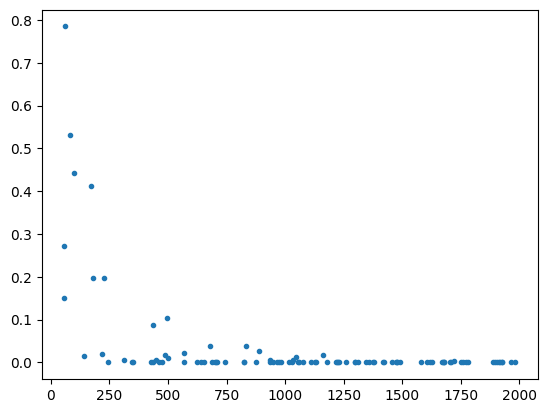

In [48]:
plt.plot(bvals,S, ".")

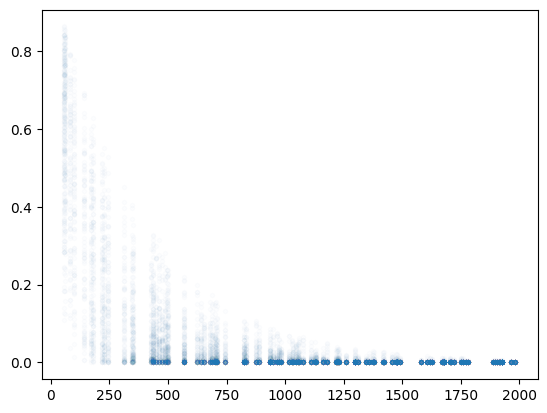

In [49]:
def pred(theta):
    m = type(model).from_theta(theta)
    S = m.signal(bvals, bvecs)
    return S

predictive = jax.vmap(pred)(jax.random.normal(jax.random.PRNGKey(0), (100, 6)))
_ = plt.plot(bvals, predictive.T,".", color="C0", alpha=0.01)

In [50]:
S_o = model.signal(bvals, bvecs)

In [51]:
theta = jnp.ones((model.theta_dim,))

def log_likelihoood(theta):
    m = type(model).from_theta(theta)
    S = m.signal(bvals, bvecs)
    return -1000*jnp.sum((S-S_o)**2) - jnp.sum(theta**2)


def pred(theta):
    m = type(model).from_theta(theta)
    S = m.signal(bvals, bvecs)
    return S

In [52]:
model.theta_dim

6

In [53]:
log_likelihoood(theta)

Array(-1775.6495, dtype=float32)

In [54]:
params = model.fit(logS, bvals, bvecs)

model.to_theta(*params)

Array([ 2.820909  , -2.610594  ,  1.0569427 ,  0.40999132,  0.51831704,
        0.7463062 ], dtype=float32)

In [71]:
from functools import partial


kernel = HMC(log_likelihoood, num_integration_steps=5)

@partial(jax.jit, static_argnums=(1,))
def sample(key, num_samples):
    params = model.fit(logS, bvals, bvecs)
    init_params = model.to_theta(*params)
    mcmc = MCMC(kernel, verbose=True)
    params_mcmc = kernel.init_params(init_params, step_size=2e-2)
    state = kernel.init(init_params)
    samples = mcmc.sample(key, state,num_samples, params_mcmc, thin=20)
    return samples[0]

In [73]:
samples = sample(jax.random.key(2), 5000)

In [74]:
samples.var(0)

Array([0.06981656, 0.04299036, 0.05864226, 0.12999624, 0.16212358,
       0.431982  ], dtype=float32)

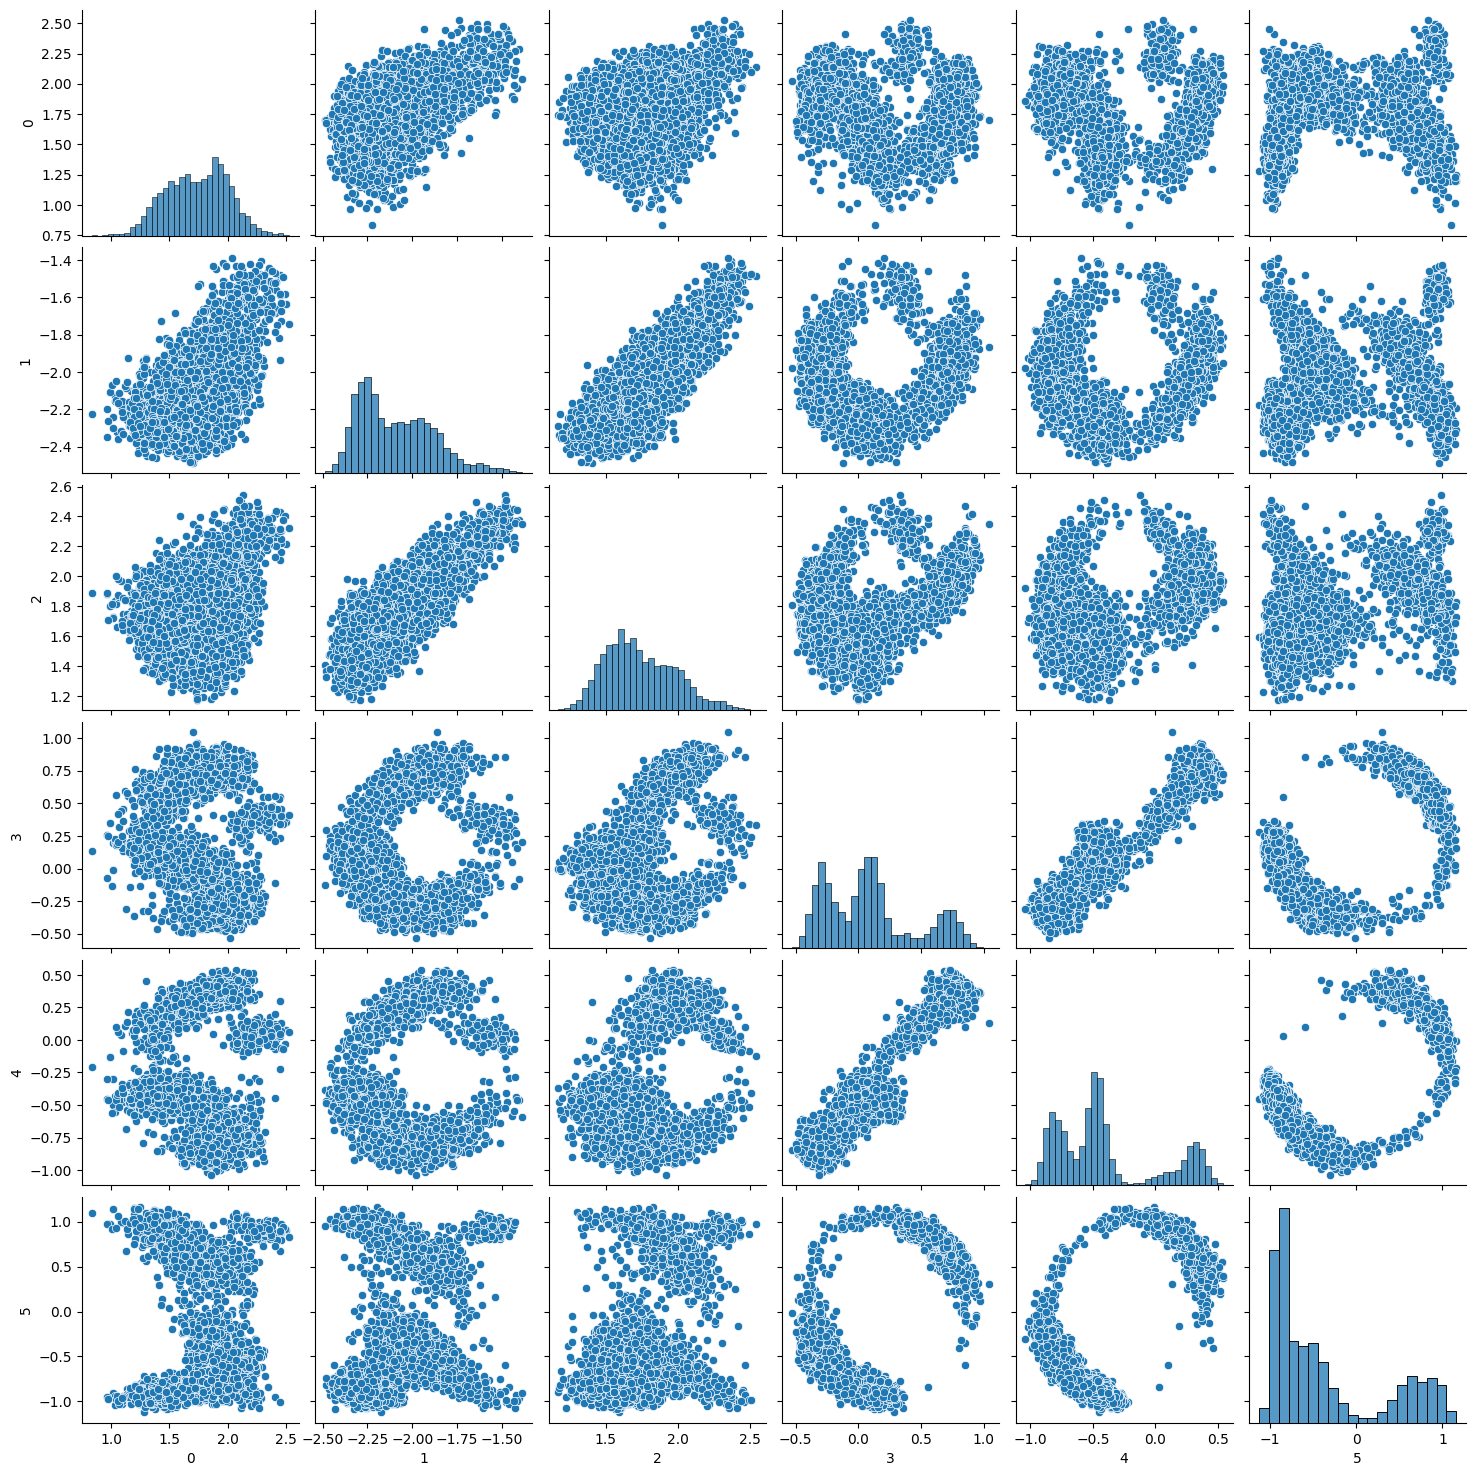

In [75]:
import pandas as pd
import seaborn as sns

df = pd.DataFrame(samples)
sns.pairplot(df)

In [76]:
S_pred = jax.vmap(pred)(samples)

Text(0, 0.5, 'Signal')

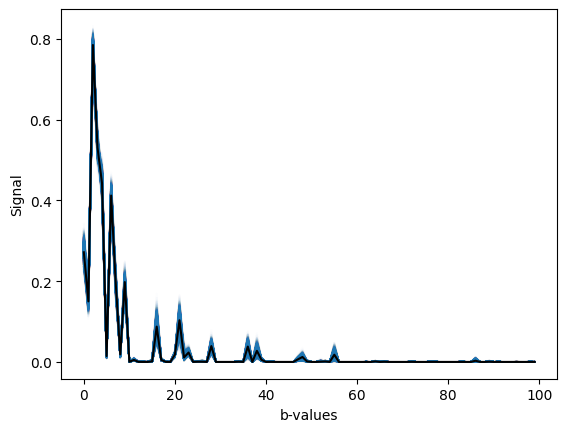

In [77]:
plt.plot(S_pred.T, alpha=0.01, color="C0")
plt.plot(S_o, color="black")
plt.xlabel("b-values")
plt.ylabel("Signal")